In [ ]:
# SETUP & IMPORTS

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Statistical summaries
from scipy import stats

# Visualization (static and interactive)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine learning preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

# Display settings for pandas
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

# For displaying multiple outputs in a cell
from IPython.display import display

In [ ]:
# LOAD AND EXPLORE THE DATASET
patient_ot_df=pd.read_csv('/content/patient_insurance_dataset.csv')
patient_ot_df.head()

,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0
3,P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09,286,1
4,P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07,319,0


In [ ]:
# Show shape
print('Shape:', patient_ot_df.shape)

# Show data types
print('\nData Types:')
print(patient_ot_df.dtypes)

# Show statistical summary (include all columns)
display(patient_ot_df.describe(include='all'))

# Show value counts for all categorical columns
categorical_cols = patient_ot_df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    print(f'\nValue counts for {col}:')
    display(patient_ot_df[col].value_counts())

Shape: (2000, 16)

Data Types:
PatientID                  object
Age                         int64
Gender                     object
State                      object
City                       object
Height_cm                   int64
Weight_kg                   int64
BMI                       float64
Insurance_Type             object
Primary_Condition          object
Num_Chronic_Conditions      int64
Annual_Visits               int64
Avg_Billing_Amount        float64
Last_Visit_Date            object
Days_Since_Last_Visit       int64
Preventive_Care_Flag        int64
dtype: object


,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
count,2000,2000.00000,2000,2000,2000,2000.000000,2000.000000,2000.000000,2000,1505,2000.000000,2000.000000,2000.000000,2000,2000.000000,2000.000000
unique,2000,NaN,2,10,20,NaN,NaN,NaN,4,9,NaN,NaN,NaN,364,NaN,NaN
top,P11983,NaN,Female,NC,Unknown,NaN,NaN,NaN,Medicare,Hypertension,NaN,NaN,NaN,2025-07-03,NaN,NaN
freq,1,NaN,1001,213,1012,NaN,NaN,NaN,906,210,NaN,NaN,NaN,13,NaN,NaN
mean,NaN,50.69550,NaN,NaN,NaN,167.907500,85.143500,30.740650,NaN,NaN,1.080000,5.466500,4000.270500,NaN,180.085000,0.464000
std,NaN,15.44445,NaN,NaN,NaN,12.684494,20.385428,8.839952,NaN,NaN,0.890504,3.485965,2463.239215,NaN,104.688484,0.498827
min,NaN,18.00000,NaN,NaN,NaN,145.000000,50.000000,13.400000,NaN,NaN,0.000000,1.000000,207.000000,NaN,1.000000,0.000000
25%,NaN,40.00000,NaN,NaN,NaN,158.000000,67.000000,23.800000,NaN,NaN,1.000000,3.000000,2061.000000,NaN,90.000000,0.000000
50%,NaN,51.00000,NaN,NaN,NaN,168.000000,86.000000,30.100000,NaN,NaN,1.000000,4.000000,3707.250000,NaN,183.000000,0.000000
75%,NaN,63.25000,NaN,NaN,NaN,177.000000,103.000000,37.025000,NaN,NaN,1.000000,8.000000,5650.875000,NaN,268.000000,1.000000



Value counts for PatientID:


,count
PatientID,
P11983,1
P11982,1
P11981,1
P11980,1
P11979,1
...,...
P10004,1
P10003,1
P10002,1



Value counts for Gender:


...

,count
Insurance_Type,
Medicare,906
Private,545
Medicaid,483
Self-Pay,66



Value counts for Primary_Condition:


,count
Primary_Condition,
Hypertension,210
Obesity,183
Anxiety,175
Arthritis,163
Asthma,160
Depression,160
Diabetes,158
Heart Disease,150
COPD,146



Value counts for Last_Visit_Date:


,count
Last_Visit_Date,
2025-07-03,13
2025-11-27,13
2025-07-15,12
2025-12-25,12
2025-09-24,12
...,...
2025-07-28,1
2025-09-25,1
2025-04-09,1


In [ ]:
# DATA CLEANING

# Check for missing (NaN) values in each column
missing_counts = patient_ot_df.isna().sum()
missing_percent = (missing_counts / len(patient_ot_df)) * 100

import pandas as pd
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent': missing_percent.round(2)
})

print('Missing values summary:')
display(missing_summary)

Missing values summary:


,Missing Count,Missing Percent
PatientID,0,0.00
Age,0,0.00
Gender,0,0.00
State,0,0.00
City,0,0.00
Height_cm,0,0.00
Weight_kg,0,0.00
BMI,0,0.00
Insurance_Type,0,0.00
Primary_Condition,495,24.75


In [ ]:
import numpy as np

# Define placeholder values to consider as missing
missing_placeholders = ["Unknown", "None"]

# Replace placeholder values with np.nan
patient_ot_df_replaced = patient_ot_df.replace(missing_placeholders, np.nan)

# Save the result in df_with_na
df_with_na = patient_ot_df_replaced.copy()

# Check for missing values again
missing_counts = df_with_na.isna().sum()
missing_percent = (missing_counts / len(df_with_na)) * 100

import pandas as pd
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent': missing_percent.round(2)
})

print('Missing values summary (including placeholders as missing):')
display(missing_summary)

Missing values summary (including placeholders as missing):


,Missing Count,Missing Percent
PatientID,0,0.00
Age,0,0.00
Gender,0,0.00
State,0,0.00
City,1012,50.60
Height_cm,0,0.00
Weight_kg,0,0.00
BMI,0,0.00
Insurance_Type,0,0.00
Primary_Condition,495,24.75


In [ ]:
# Fill missing values in 'Primary_Condition' with 'No Condition'
patient_df_nonan = df_with_na.copy()
patient_df_nonan['Primary_Condition'] = patient_df_nonan['Primary_Condition'].fillna('No Condition')

# Verify the replacement
missing_primary_condition = patient_df_nonan['Primary_Condition'].isna().sum()
unique_primary_conditions = patient_df_nonan['Primary_Condition'].unique()

print(f"Missing values in 'Primary_Condition' after filling: {missing_primary_condition}")
print(f"Unique values in 'Primary_Condition': {unique_primary_conditions}")

Missing values in 'Primary_Condition' after filling: 0
Unique values in 'Primary_Condition': ['Arthritis' 'Depression' 'Asthma' 'Hypertension' 'Anxiety' 'No Condition'
 'Heart Disease' 'Obesity' 'COPD' 'Diabetes']


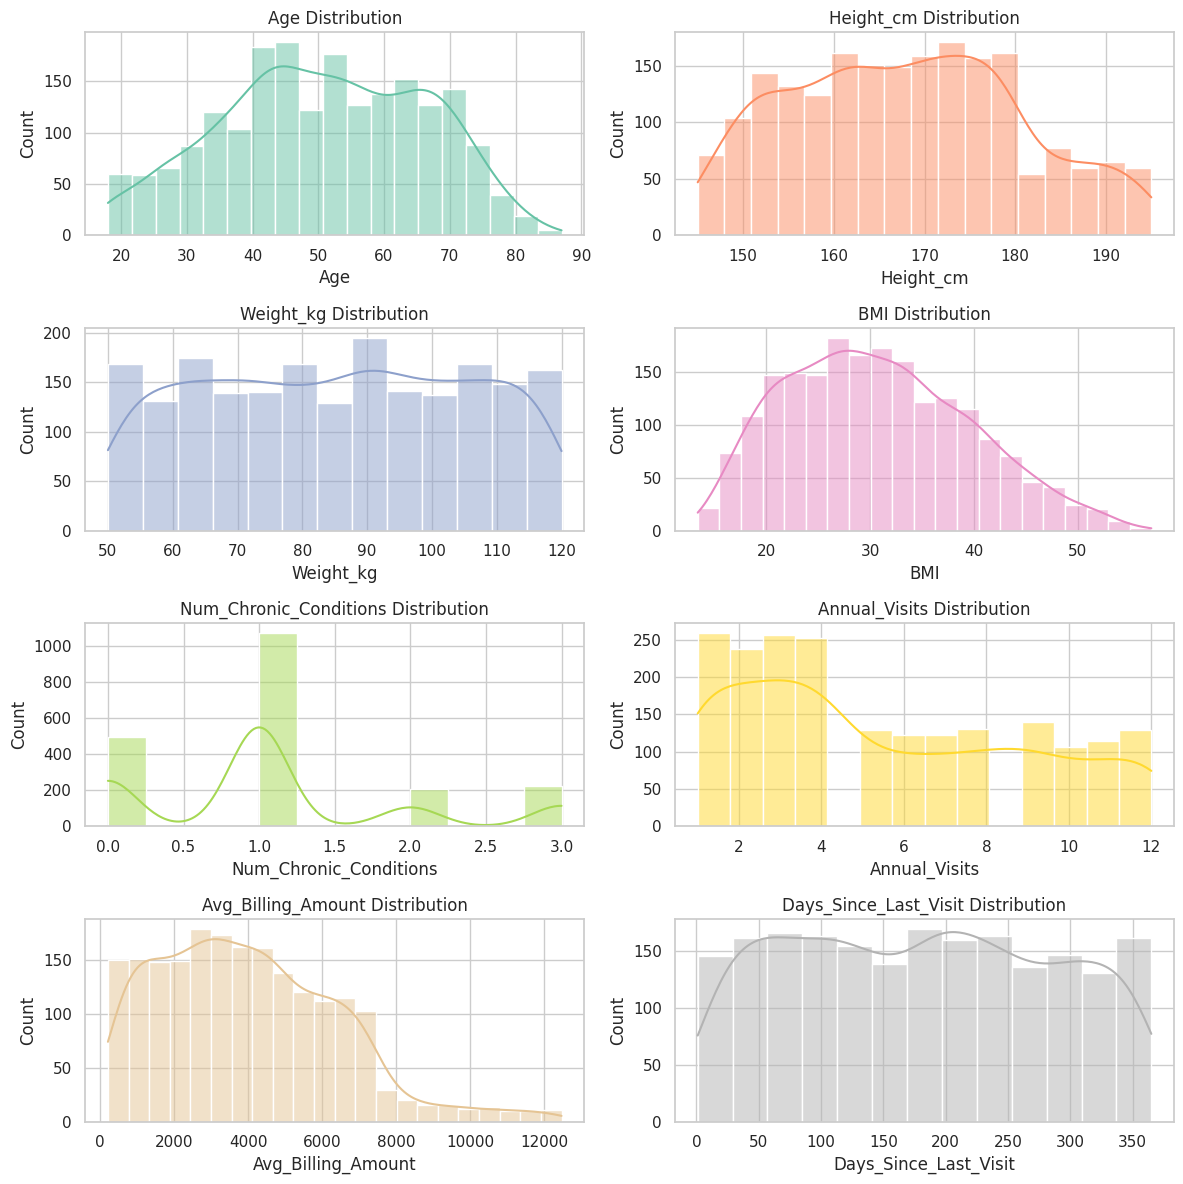

/tmp/ipykernel_3342/1642984234.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=patient_df_nonan[col], ax=axes[i], palette="Set2")
/tmp/ipykernel_3342/1642984234.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=patient_df_nonan[col], ax=axes[i], palette="Set2")
/tmp/ipykernel_3342/1642984234.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=patient_df_nonan[col], ax=axes[i], palette="Set2")


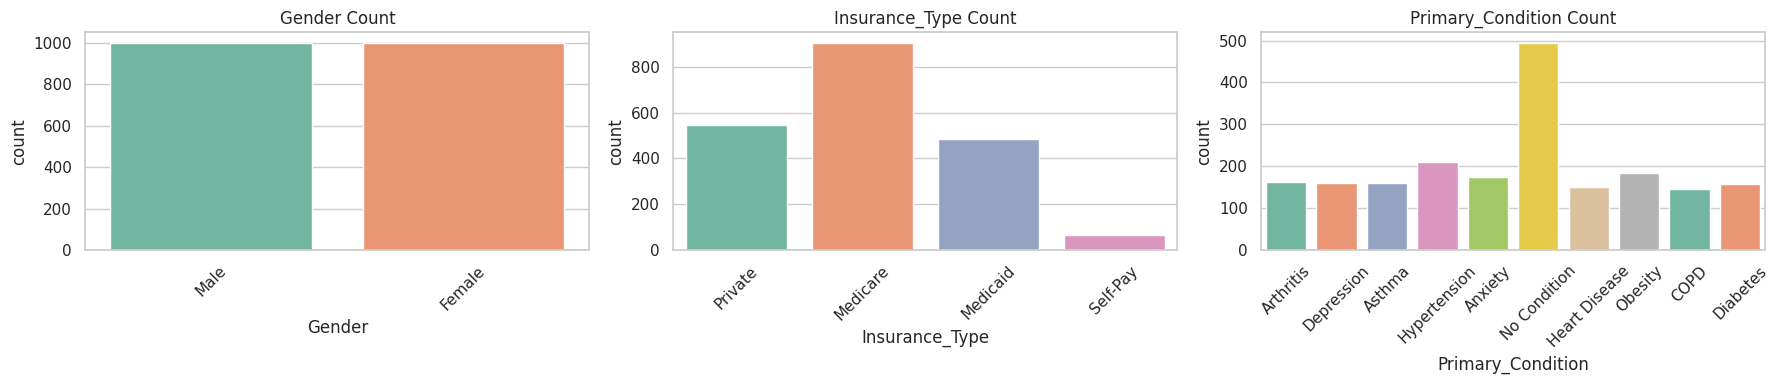

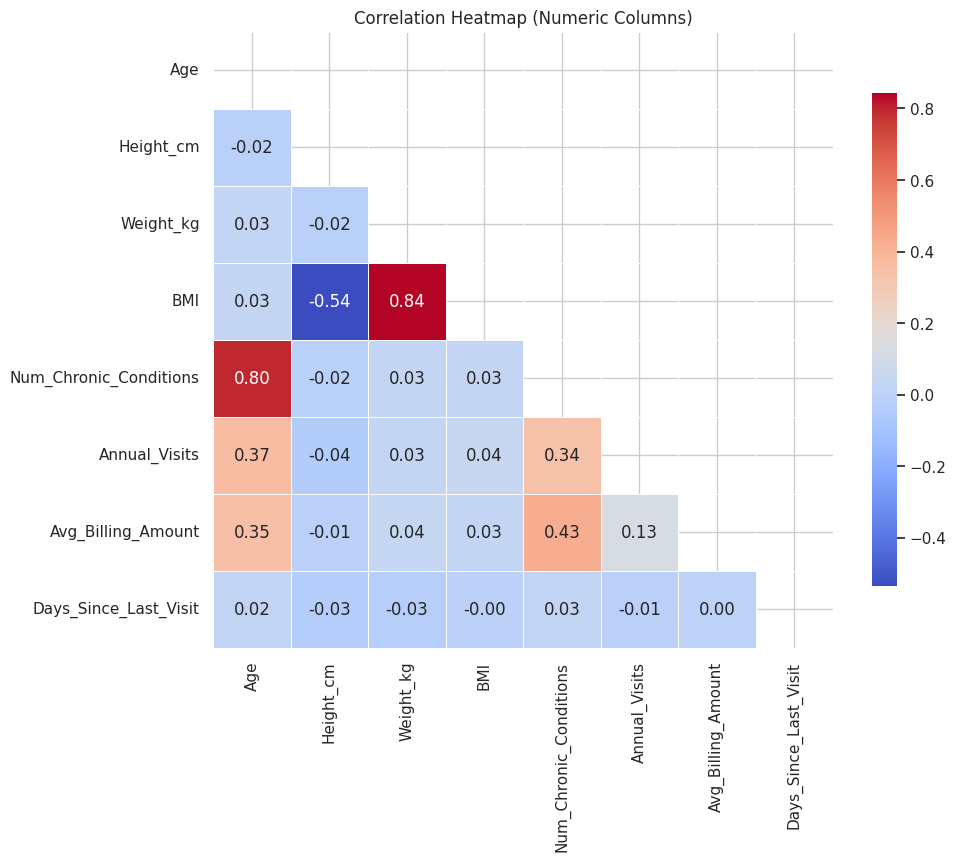

In [ ]:
# EXPLORATORY DATA ANALYSIS
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set style and palette
sns.set(style="whitegrid", palette="Set2")

# Select numeric and categorical columns
numeric_cols = [
    'Age', 'Height_cm', 'Weight_kg', 'BMI', 'Num_Chronic_Conditions',
    'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit'
]
categorical_cols = ['Gender', 'Insurance_Type', 'Primary_Condition']

# Plot grid of histograms with KDE for numeric columns
n_num = len(numeric_cols)
fig, axes = plt.subplots(nrows=(n_num + 1) // 2, ncols=2, figsize=(12, 3 * ((n_num + 1) // 2)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(patient_df_nonan[col], kde=True, ax=axes[i], color=sns.color_palette("Set2")[i % 8])
    axes[i].set_title(f"{col} Distribution")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# Count plots for categorical columns
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(categorical_cols):
    sns.countplot(x=patient_df_nonan[col], ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} Count")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Correlation heatmap for numeric columns
corr = patient_df_nonan[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title("Correlation Heatmap (Numeric Columns)")
plt.show()

In [ ]:
# CLUSTERING
# Select specified numerical and categorical columns
numerical_cols = [
    'Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit'
]
categorical_cols = [
    'Gender', 'Insurance_Type', 'Primary_Condition'
]
selected_cols = numerical_cols + categorical_cols

patients_final_df = patient_df_nonan[selected_cols]

# Display the first few rows to verify
patients_final_df.head()

,Age,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Gender,Insurance_Type,Primary_Condition
0,64,50.4,3,7,2995.0,186,Male,Private,Arthritis
1,59,19.0,1,8,1209.0,39,Male,Medicare,Depression
2,58,37.4,1,4,999.0,126,Female,Private,Asthma
3,43,39.8,1,6,5638.5,286,Female,Medicare,Hypertension
4,53,18.3,1,4,5796.0,319,Female,Medicaid,Asthma


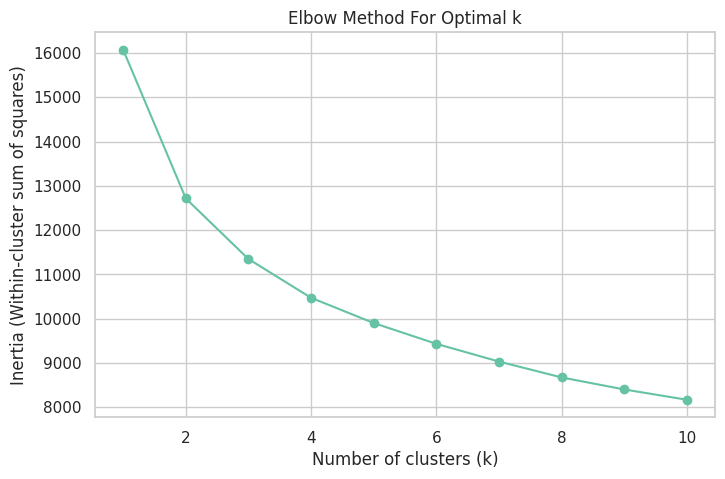

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Define columns
numerical_cols = [
    'Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit'
]
categorical_cols = [
    'Gender', 'Insurance_Type', 'Primary_Condition'
]

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(sparse_output=False), categorical_cols)
])

# Prepare data for clustering
X = preprocessor.fit_transform(patients_final_df)

# Elbow method to find optimal k
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import plotly.express as px
import numpy as np

# Find the elbow point (optimal k) - usually where the inertia starts to decrease more slowly
# For automation, we can use the "knee" point, but here let's pick k=3 as a common choice, or you can adjust as needed
optimal_k = 3  # Change this if you visually identified a different k from the elbow plot

# Fit KMeans with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Reduce to 2D with PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels.astype(str)
})

# Plot with Plotly
fig = px.scatter(
    plot_df, x='PC1', y='PC2', color='Cluster',
    title=f'K-Means Clusters (k={optimal_k}) in 2D PCA Space',
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig.show()